## Diabetes prediction and Health risk analysis

In [38]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset understanding

In [39]:

df = pd.read_csv("../data/raw/dataset.csv", header=None)

df.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [40]:
df.shape 

(768, 9)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [42]:
df.nunique() #this tell us that how many distinct values occur in each column

0     17
1    136
2     47
3     51
4    186
5    248
6    517
7     52
8      2
dtype: int64

In [43]:
df[8].value_counts()

8
0    500
1    268
Name: count, dtype: int64

In [44]:
df.describe()

,0,1,2,3,4,5,6,7,8
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [45]:
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
] #this doesnt change the actual csv but just the dataframe(df)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [46]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [47]:
zero_counts = (df == 0).sum()
zero_counts

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [48]:
zero_counts / len(df) * 100 # this gives in percentage the number of zeros

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

### Data cleaning part

In [49]:
missing_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df_clean = df.copy() # this creates new dataframe and we preserve the original df 
df_clean[missing_zero_columns] = df_clean[missing_zero_columns].replace(0,np.nan) #tyo column ma jaha zero nahuna parney zero xa vaney tini haru lai replace garxa with nan
df_clean.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

we do not drop these rows cause insulin ra skinthickness ma we lose large amount of data so we find a way to quantify this

In [50]:
missing_percentage = df_clean.isna().mean() * 100
missing_percentage

Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

In [51]:
df_clean.shape

(768, 9)

In [52]:
df.shape

(768, 9)

In [53]:
df_clean.duplicated().sum()

np.int64(0)

In [54]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


As you can see max value of insulin is 846 and skin thickness 99 that means highly skewed xa dataset outlier is present so to check it we use Iqr based outlier count.

In [55]:
numeric_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
Q1=df_clean[numeric_columns].quantile(0.25) #25% of observed values lie 
Q3 = df_clean[numeric_columns].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df_clean[numeric_columns] < lower_bound) |
    (df_clean[numeric_columns] > upper_bound)
).sum() # is the value either below the lower bound or above the upper bound and we sum them all b

outlier_counts

Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness                3
Insulin                     24
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
dtype: int64

### Data preprocessing


In [56]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X.shape, y.shape

((768, 8), (768,))

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [58]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Outcome
 0    0.651466
 1    0.348534
 Name: proportion, dtype: float64,
 Outcome
 0    0.649351
 1    0.350649
 Name: proportion, dtype: float64)

In [59]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train) #this changes the data into numpy array
X_test_imputed = imputer.transform(X_test) #the data is fitted using the train data and filled it into the test data as well

yesma imputer changes the data into array ani we fill the median value from x_train_only in both of the x test and train x

In [60]:
np.isnan(X_train_imputed).sum(), np.isnan(X_test_imputed).sum() #all the missing values were imputed

(np.int64(0), np.int64(0))

In [61]:
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)
#converting the array into dataframe

In [62]:
X_train_imputed.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0
711,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0
373,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0
46,1.0,146.0,56.0,29.0,125.0,29.7,0.564,29.0
682,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0


In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed) #xtrain =fit + transform
X_test_scaled = scaler.transform(X_test_imputed) #transform only

In [64]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)
#converting the array into dataframe

In [65]:
X_train_scaled.mean(axis=0), X_train_scaled.std(axis=0) #mean = 0 and std = 1

(Pregnancies                -6.943414e-17
 Glucose                    -1.099374e-16
 BloodPressure               3.095606e-16
 SkinThickness              -3.471707e-17
 Insulin                    -4.339634e-18
 BMI                         1.649061e-16
 DiabetesPedigreeFunction   -1.099374e-16
 Age                        -1.084908e-16
 dtype: float64,
 Pregnancies                 1.000815
 Glucose                     1.000815
 BloodPressure               1.000815
 SkinThickness               1.000815
 Insulin                     1.000815
 BMI                         1.000815
 DiabetesPedigreeFunction    1.000815
 Age                         1.000815
 dtype: float64)

conclusion:
we did train/split in the first part. x contains 8 columns and y contains outcome. and we impute using median value and later we scaled the value as well and we did the calculation on the train data only and filled test data with the data from the train

### EDA(Exploratory Data Analysis)

#Goal of Eda
- How is the target (Outcome) distributed?
- What do the feature distributions look like?
- Are there skewed or unusual variables?
- How do features differ between diabetic and non-diabetic groups?
- Are some features strongly related to each other?
- Are there patterns that should influence feature engineering or model selection?

In [66]:
y.value_counts() , y.value_counts(normalize=True) * 100 # there is a moderate class imbalance

(Outcome
 0    500
 1    268
 Name: count, dtype: int64,
 Outcome
 0    65.104167
 1    34.895833
 Name: proportion, dtype: float64)

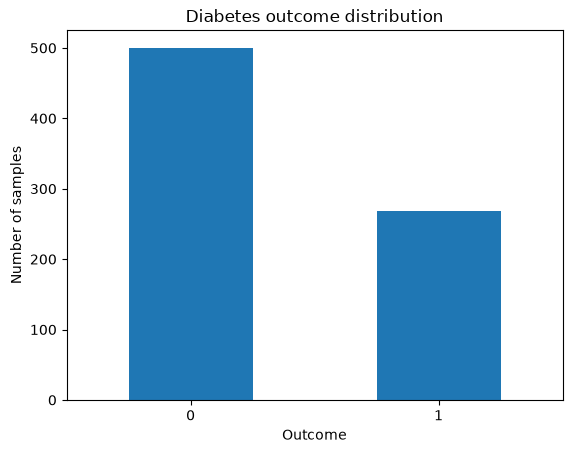

In [67]:
y.value_counts().plot(kind="bar")

plt.title("Diabetes outcome distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)

plt.show()

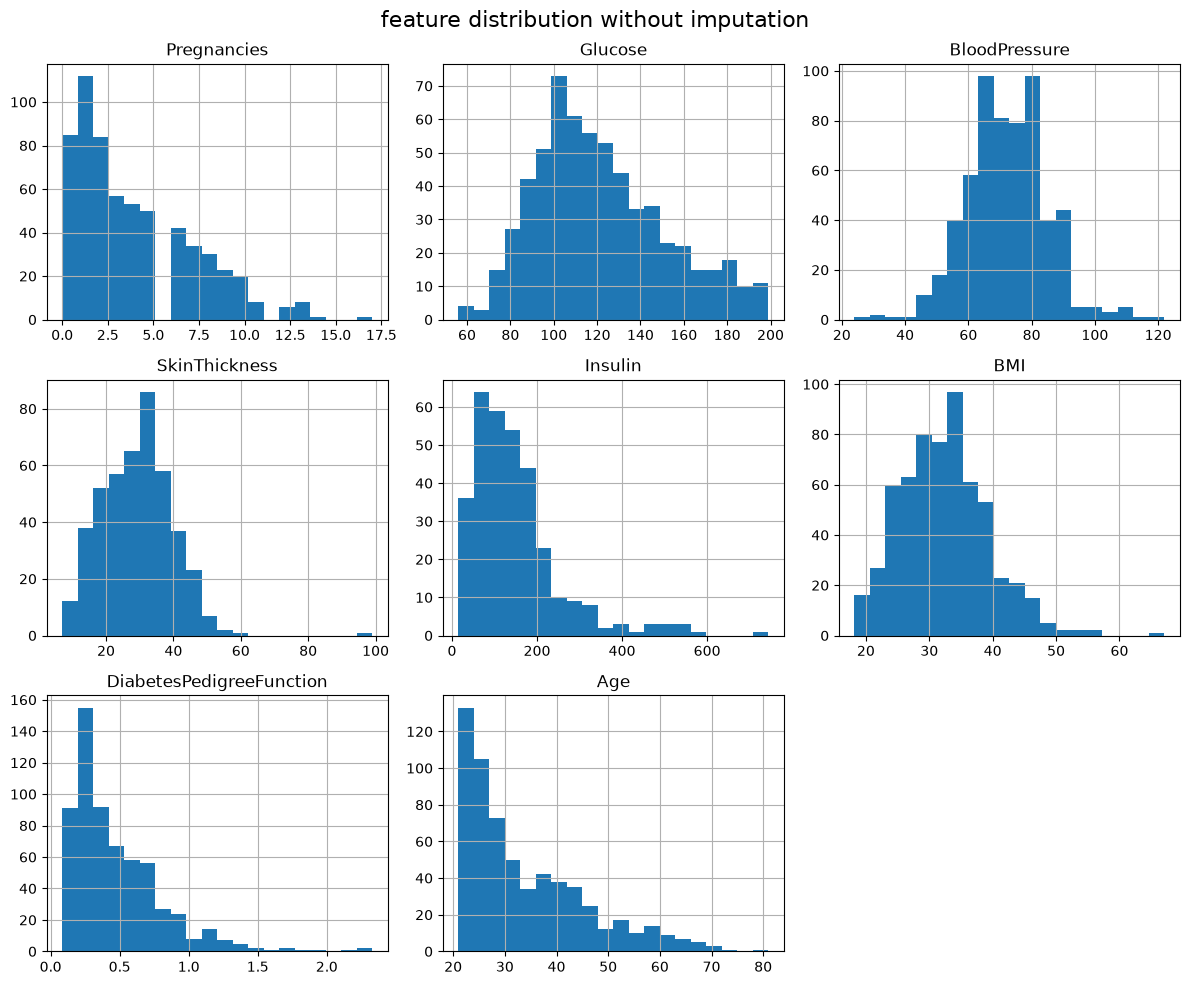

In [68]:
X_train.hist(figsize=(12,10),bins=20)
plt.suptitle("feature distribution without imputation",fontsize=16)
plt.tight_layout()
plt.show()

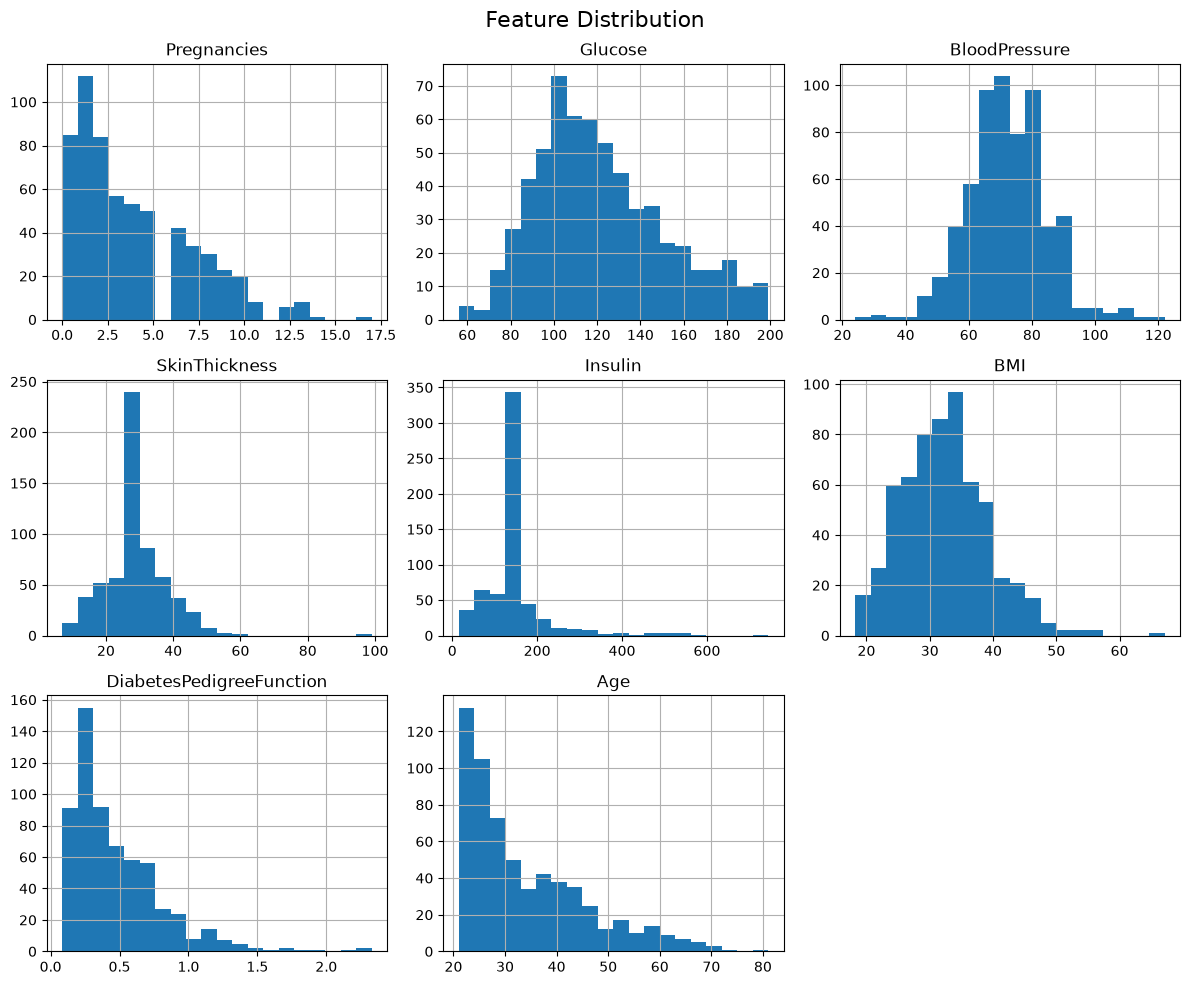

In [69]:
X_train_imputed.hist(figsize=(12,10),bins=20) #12 wide and 10 tall in inches

plt.suptitle("Feature Distribution",fontsize=16)
plt.tight_layout() #adjust spacking so subplt title ,axis label and the main title dont overlap
plt.show()

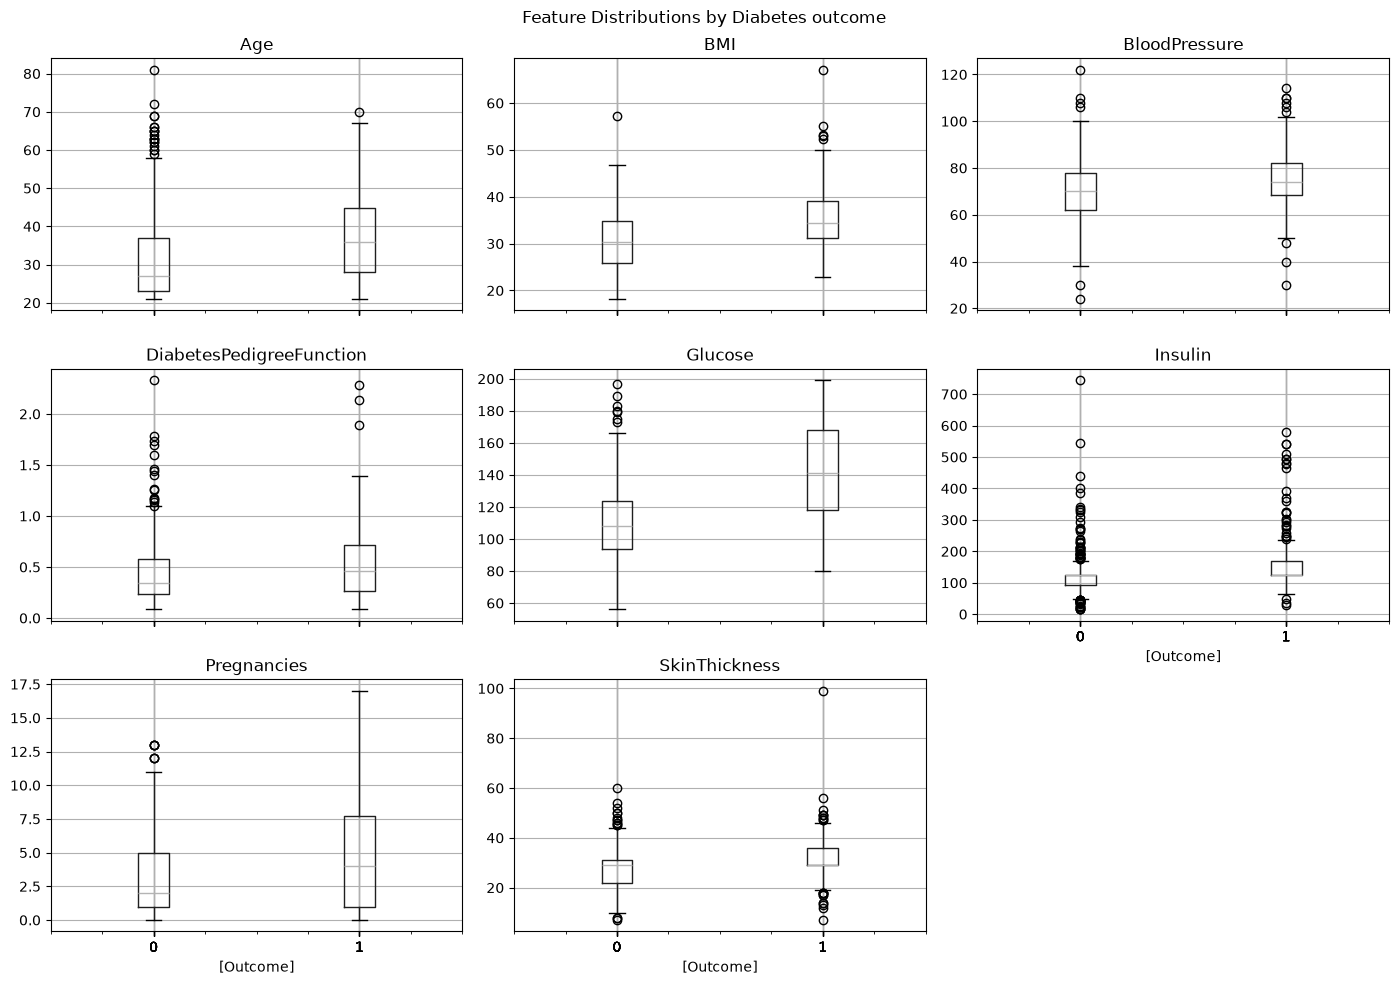

In [70]:
#comparing features by outcome do feature distributions look different between people with outcome =0 and outcome = 1

X_train_imputed.assign(Outcome = y_train).boxplot(
    by = "Outcome",
    figsize=(14,10),
    layout=(3,3),
    sharey=False
)
plt.suptitle("Feature Distributions by Diabetes outcome")
plt.tight_layout()
plt.show() #left is 0 and right is 1

In [71]:
eda_df = X_train_imputed.copy()
eda_df["Outcome"] = y_train

correlation_matrix = eda_df.corr()
print(correlation_matrix["Outcome"].sort_values(ascending=False)) #correlation with outcome or target

Outcome                     1.000000
Glucose                     0.512291
BMI                         0.328774
Insulin                     0.245902
Age                         0.240676
SkinThickness               0.234260
Pregnancies                 0.208173
BloodPressure               0.183373
DiabetesPedigreeFunction    0.165312
Name: Outcome, dtype: float64


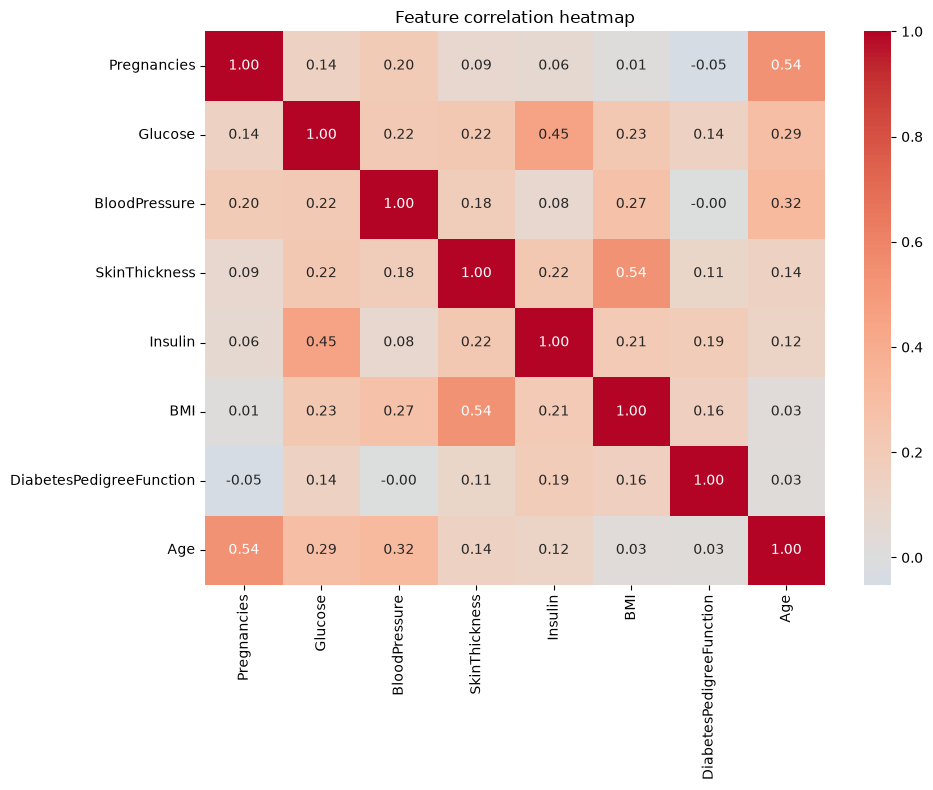

In [72]:
feature_corr = X_train_imputed.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [73]:
skewness = X_train_imputed.skew().sort_values(ascending=False)
print(skewness) #=0 roughly symmetric like a bell curve >0 right-skewed and <0 left-skewed

Insulin                     3.076431
DiabetesPedigreeFunction    1.818910
Age                         1.128456
Pregnancies                 0.886920
SkinThickness               0.886446
BMI                         0.573822
Glucose                     0.556834
BloodPressure               0.115048
dtype: float64


# Handling Skewed Data: Short Notes

##  Apply a Transformation

Choose based on skew direction and severity.

| Skew type | Transformations |
|---|---|
| Right-skewed (positive) | log, log1p, square root, Box-Cox, Yeo-Johnson |
| Left-skewed (negative) | Reflect then log (`log(max+1 - x)`), square, Yeo-Johnson |
| Any, incl. zero/negative values | Yeo-Johnson |

- `log` needs positive values; use `log1p` if zeros exist
- Box-Cox needs strictly positive values; Yeo-Johnson does not

## Do Transformations Make Data Incorrect?

No. They change the **scale**, not the **information**.

- Monotonic (log, sqrt, Box-Cox, Yeo-Johnson), so the **order is preserved**
- **Reversible** with `inverse_transform` if the fitted transformer is kept
- Models learn patterns, not real-world units
- Compressing extreme values stops a few large values from dominating
- Similar to viewing data on a log axis: same data, clearer structure

## Valid Concerns

- **Interpretability:** coefficients are per unit of the transformed value, not the original unit
- **Unnecessary use:** tree-based models don't need it
- **Leakage:** fit the transformer on the training set only
- **Overcorrecting:** forcing a perfect bell curve can distort relationships; mild skew is often fine to leave

## Good Practices

1. Keep the original dataframe; store transformed data separately
2. Use a pipeline so preprocessing is applied automatically to new data
3. Report results in original units (use `inverse_transform`)
4. Validate by comparing model performance with and without the transformation



In [74]:
X_train_engineered = X_train_imputed.copy()
for column in ["Insulin","DiabetesPedigreeFunction"]:
    X_train_engineered[column] = np.log1p(X_train_engineered[column]) #make remove the right skewness using log1p
    
print(X_train_engineered.skew().sort_values(ascending=False)) #result after fixing skewness

Age                         1.128456
DiabetesPedigreeFunction    1.060225
Pregnancies                 0.886920
SkinThickness               0.886446
BMI                         0.573822
Glucose                     0.556834
BloodPressure               0.115048
Insulin                    -0.364047
dtype: float64


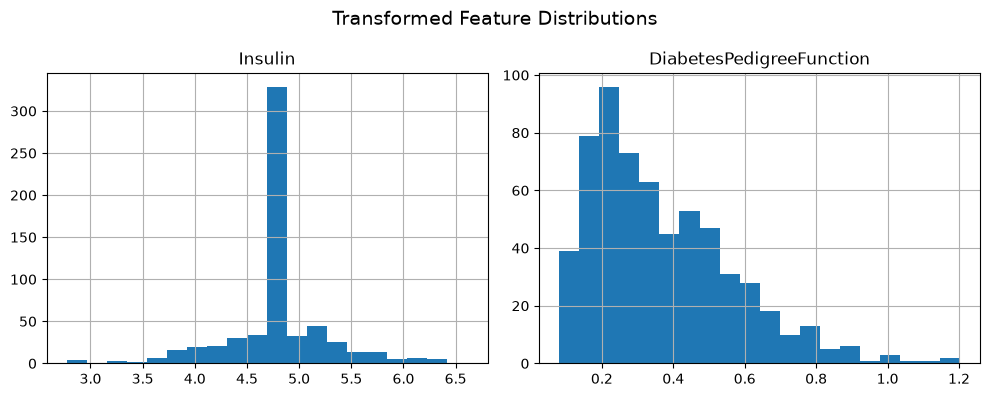

In [75]:
X_train_engineered[["Insulin", "DiabetesPedigreeFunction"]].hist(
    figsize=(10, 4),
    bins=20
)

plt.suptitle("Transformed Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
X_test_engineered = X_test_imputed.copy()

for column in ["Insulin", "DiabetesPedigreeFunction"]:
    X_test_engineered[column] = np.log1p(X_test_engineered[column])

print(X_test_engineered.shape)
print(X_test_engineered.isna().sum().sum())
print(np.isinf(X_test_engineered).sum().sum())

(154, 8)
0
0


In [77]:
scaler_final = StandardScaler()

X_train_final = scaler_final.fit_transform(X_train_engineered)
X_test_final = scaler_final.transform(X_test_engineered)

X_train_final = pd.DataFrame(
    X_train_final,
    columns=X_train_engineered.columns,
    index=X_train_engineered.index
)

X_test_final = pd.DataFrame(
    X_test_final,
    columns=X_test_engineered.columns,
    index=X_test_engineered.index
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

print("\nMissing values:")
print(X_train_final.isna().sum().sum(), X_test_final.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_train_final).sum().sum(),
      np.isinf(X_test_final).sum().sum())

Training shape: (614, 8)
Testing shape: (154, 8)

Missing values:
0 0

Infinite values:
0 0


In [78]:
print("Training means:")
print(X_train_final.mean().round(4))

print("\nTraining standard deviations:")
print(X_train_final.std().round(4))

Training means:
Pregnancies                -0.0
Glucose                    -0.0
BloodPressure               0.0
SkinThickness              -0.0
Insulin                    -0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                        -0.0
dtype: float64

Training standard deviations:
Pregnancies                 1.0008
Glucose                     1.0008
BloodPressure               1.0008
SkinThickness               1.0008
Insulin                     1.0008
BMI                         1.0008
DiabetesPedigreeFunction    1.0008
Age                         1.0008
dtype: float64
